# Эксперимент 04: 1D CNN по waveform

**Статья:** CNN Architectures for Large-Scale Audio Classification (Архитектуры CNN для крупномасштабной аудиоклассификации) 2016

**Ссылка:** [https://arxiv.org/abs/1609.09430](https://arxiv.org/abs/1609.09430)

**Краткое описание модели:** Сырая waveform-последовательность -> 1D-CNN-блоки -> классификатор.

**Содержание статьи:** 1D-CNN позволяет обучаться напрямую на сигнале без явного построения спектрограммы. Такой подход может улавливать тонкие временные особенности артикуляции. Эксперимент сравнивает эффективность «сырых» признаков с time-frequency представлениями.

In [ ]:
import sys
from pathlib import Path
import numpy as np
import time
import torch
from torch.utils.data import DataLoader
from torch import nn
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, precision_score, recall_score, classification_report
import matplotlib.pyplot as plt
import pandas as pd

exp_dir = Path().resolve()
sys.path.insert(0, str(exp_dir.parent))
sys.path.insert(0, str(exp_dir))

from shared import config, data_utils, train_utils
from shared.results_utils import save_result_csv
from model import get_model

## 1. Разбиение и датасет по waveform

In [ ]:
paths_train, paths_val, paths_test, y_train, y_val, y_test, letters_train, letters_val, letters_test = data_utils.get_splits()
print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")
n_letters = letters_train.shape[1]

SR = config.TARGET_SR
MAX_SEC = config.MAX_DURATION_SEC
MAX_LEN = int(SR * MAX_SEC)

def load_waveform(path):
    y, _ = data_utils.load_audio(path, sr=SR, max_sec=MAX_SEC)
    if len(y) < MAX_LEN:
        y = np.pad(y, (0, MAX_LEN - len(y)), mode="constant", constant_values=0)
    else:
        y = y[:MAX_LEN]
    y = y.astype(np.float32)
    # Нормализация по сэмплу для стабильности обучения
    std = y.std()
    if std > 1e-8:
        y = (y - y.mean()) / std
    return y

class WaveformDataset(torch.utils.data.Dataset):
    def __init__(self, paths, labels, letters):
        self.paths = paths
        self.labels = labels
        self.letters = letters
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        wav = load_waveform(self.paths[i])
        let = torch.from_numpy(self.letters[i].astype(np.float32))
        return torch.from_numpy(wav), let, self.labels[i]

train_ds = WaveformDataset(paths_train, y_train, letters_train)
val_ds   = WaveformDataset(paths_val, y_val, letters_val)
test_ds  = WaveformDataset(paths_test, y_test, letters_test)
print(f"Длина waveform: {MAX_LEN} сэмплов ({MAX_SEC} с)")

Train: 1942, Val: 417, Test: 417
Длина waveform: 160000 сэмплов (10.0 с)


## 2. DataLoader и модель

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

BATCH_SIZE = 32
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=(device.type=="cuda"))
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False)

Device: cuda


In [4]:
model = get_model(in_length=MAX_LEN, num_classes=2, n_letters=n_letters, dropout=0.5).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Параметров: {n_params}")

Параметров: 133554


## 3. Обучение

In [5]:
weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
weights = weights.astype(np.float32)
weights[1] *= 2.0
class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = train_utils.get_lr_scheduler(optimizer, patience=config.LR_SCHEDULER_PATIENCE, factor=config.LR_SCHEDULER_FACTOR)
early_stopping = train_utils.EarlyStopping(patience=config.EARLY_STOPPING_PATIENCE)
best_ckpt_path = exp_dir / "best_ckpt.pt"
best_f1 = -1.0

In [6]:
def eval_loader(loader):
    model.eval()
    all_pred, all_true = [], []
    with torch.no_grad():
        for x, letters, y in loader:
            x, letters, y = x.to(device), letters.to(device), y.to(device)
            logits = model(x, letters)
            pred = logits.argmax(dim=1)
            all_pred.append(pred.cpu().numpy())
            all_true.append(y.cpu().numpy())
    return np.concatenate(all_pred), np.concatenate(all_true)

N_EPOCHS = 50
train_losses, val_f1s = [], []

t0 = time.perf_counter()
for epoch in range(N_EPOCHS):
    model.train()
    epoch_losses = []
    for x, letters, y in train_loader:
        x, letters, y = x.to(device), letters.to(device), y.to(device)
        optimizer.zero_grad()
        loss = criterion(model(x, letters), y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=config.DEFAULT_GRAD_CLIP)
        optimizer.step()
        epoch_losses.append(loss.item())
    train_losses.append(np.mean(epoch_losses))
    vp, vt = eval_loader(val_loader)
    val_f1 = f1_score(vt, vp, average="macro")
    val_f1s.append(val_f1)
    if val_f1 > best_f1:
        best_f1 = val_f1
        train_utils.save_best_checkpoint(model, best_ckpt_path)
    scheduler.step(val_f1)
    print(f"Epoch {epoch+1}/{N_EPOCHS}  train_loss={train_losses[-1]:.4f}  val_f1_macro={val_f1:.4f}")
    if early_stopping.step(val_f1):
        print(f"Early stopping на эпохе {epoch+1}")
        break
train_time_sec = time.perf_counter() - t0
train_utils.load_best_checkpoint(model, best_ckpt_path, device)
print(f"Обучение заняло {train_time_sec:.1f} с. Загружен лучший чекпоинт (val_f1_macro={best_f1:.4f}).")

Epoch 1/50  train_loss=0.6498  val_f1_macro=0.4588
Epoch 2/50  train_loss=0.6275  val_f1_macro=0.3394
Epoch 3/50  train_loss=0.6206  val_f1_macro=0.4539
Epoch 4/50  train_loss=0.6104  val_f1_macro=0.4854
Epoch 5/50  train_loss=0.6051  val_f1_macro=0.3203
Epoch 6/50  train_loss=0.5999  val_f1_macro=0.4007
Epoch 7/50  train_loss=0.5816  val_f1_macro=0.5683
Epoch 8/50  train_loss=0.5683  val_f1_macro=0.6498
Epoch 9/50  train_loss=0.5798  val_f1_macro=0.6111
Epoch 10/50  train_loss=0.5611  val_f1_macro=0.5731
Epoch 11/50  train_loss=0.5624  val_f1_macro=0.7076
Epoch 12/50  train_loss=0.5433  val_f1_macro=0.5181
Epoch 13/50  train_loss=0.5378  val_f1_macro=0.7184
Epoch 14/50  train_loss=0.5329  val_f1_macro=0.2988
Epoch 15/50  train_loss=0.5292  val_f1_macro=0.4840
Epoch 16/50  train_loss=0.5043  val_f1_macro=0.6725
Epoch 17/50  train_loss=0.4923  val_f1_macro=0.2988
Epoch 18/50  train_loss=0.4810  val_f1_macro=0.3611
Epoch 19/50  train_loss=0.4656  val_f1_macro=0.2613
Epoch 20/50  train_lo

## 4. Оценка на тесте и метрики

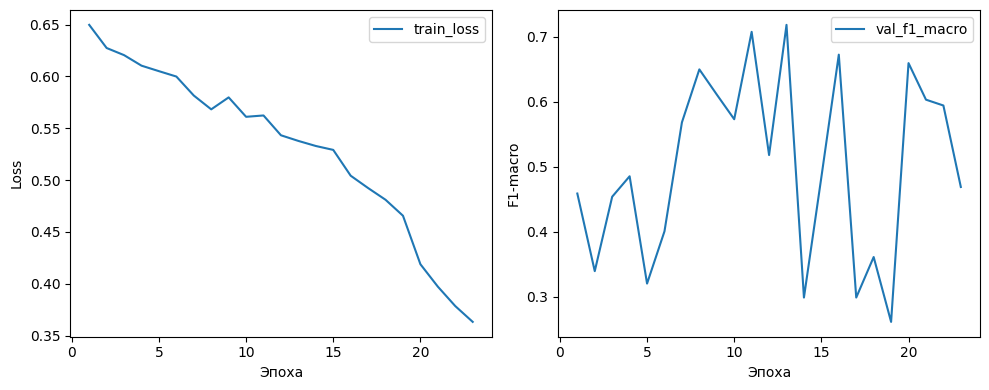

In [7]:
n_epochs_done = len(train_losses)
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(range(1, n_epochs_done + 1), train_losses, label="train_loss")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(range(1, n_epochs_done + 1), val_f1s, label="val_f1_macro")
plt.xlabel("Эпоха")
plt.ylabel("F1-macro")
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
model.eval()
all_logits = []
with torch.no_grad():
    for x, letters, _ in test_loader:
        x, letters = x.to(device), letters.to(device)
        all_logits.append(model(x, letters).cpu().numpy())
logits = np.concatenate(all_logits)
y_pred = np.argmax(logits, axis=1)
y_proba = torch.softmax(torch.from_numpy(logits), dim=1).numpy()[:, config.CLASS_BAD]

accuracy = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_bad   = f1_score(y_test, y_pred, pos_label=config.CLASS_BAD)
roc_auc  = roc_auc_score(y_test, y_proba)
precision_bad = precision_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)
recall_bad    = recall_score(y_test, y_pred, pos_label=config.CLASS_BAD, zero_division=0)

print(classification_report(y_test, y_pred, target_names=config.CLASS_NAMES))
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print(f"F1 (bad): {f1_bad:.4f}")
print(f"ROC-AUC:  {roc_auc:.4f}")

metrics_table = pd.DataFrame([{
    "accuracy": accuracy, "f1_macro": f1_macro, "f1_bad": f1_bad,
    "roc_auc": roc_auc, "precision_bad": precision_bad, "recall_bad": recall_bad,
}])
print("\nТаблица метрик (тест):")
display(metrics_table)

              precision    recall  f1-score   support

        good       0.78      0.85      0.82       282
         bad       0.62      0.51      0.56       135

    accuracy                           0.74       417
   macro avg       0.70      0.68      0.69       417
weighted avg       0.73      0.74      0.73       417

Accuracy: 0.7410
F1 macro: 0.6887
F1 (bad): 0.5610
ROC-AUC:  0.7645

Таблица метрик (тест):


,accuracy,f1_macro,f1_bad,roc_auc,precision_bad,recall_bad
0,0.741007,0.688651,0.560976,0.76446,0.621622,0.511111


## 5. Запись метрик в общий файл

In [ ]:
save_result_csv(
    exp_dir=exp_dir,
    experiment_id="exp_04_1d_cnn",
    experiment_name="1D CNN на waveform",
    model="WaveformCNN1d",
    accuracy=accuracy,
    f1_macro=f1_macro,
    f1_bad=f1_bad,
    roc_auc=roc_auc,
    precision_bad=precision_bad,
    recall_bad=recall_bad,
    notes="raw waveform 10s 16kHz, 4 blocks Conv1d 32-64-128-256",
    num_params=n_params,
    train_time_sec=train_time_sec,
)